# Запуск экспериментов

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib

import sys

sys.path.append("/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/1")

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/1/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

print("device:", device)

torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda


## Базовый конфиг

In [3]:
base_config = {
    "task_name": "heat1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "alpha": 0.1,
    "hid_size": 64,
    "num_layers": 4,
    "n_collocation": 2000,
    "n_ic": 200,
    "n_bc": 200,
    "adam_steps": 3000,
    "lbfgs_steps": 300,
    "lr_adam": 1e-3,
    "use_adam": True,
    "use_lbfgs": True,
    "log_dir": "/kaggle/working/runs/heat1d_fp32_0",
}

## Быстрая проверка

In [4]:
smoke_config = base_config.copy()
smoke_config["hid_size"] = 16
smoke_config["num_layers"] = 2
smoke_config["n_collocation"] = 100
smoke_config["n_ic"] = 30
smoke_config["n_bc"] = 30
smoke_config["adam_steps"] = 20
smoke_config["lbfgs_steps"] = 5
smoke_config["log_dir"] = "/kaggle/working/runs/smoke_heat1d_fp32_seed0"

pinn_model = importlib.reload(pinn_model)
smoke_history, smoke_summary = pinn_model.run_experiment(smoke_config)
smoke_summary

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'task_name': 'heat1d',
 'dtype': 'fp32',
 'seed': 0,
 'alpha': 0.1,
 'hid_size': 16,
 'num_layers': 2,
 'n_collocation': 100,
 'n_ic': 30,
 'n_bc': 30,
 'adam_steps': 20,
 'lbfgs_steps': 5,
 'final_loss': 0.2796403467655182,
 'final_l2_error': 0.6445148587226868,
 'time_sec': 8.20943284034729,
 'log_dir': '/kaggle/working/runs/smoke_heat1d_fp32_seed0'}

## Один запуск fp32

In [5]:
config = base_config.copy()
config["dtype"] = "fp32"
config["seed"] = 0
config["log_dir"] = "runs/heat1d_fp32_seed0"

history32, summary32 = pinn_model.run_experiment(config)
summary32

{'task_name': 'heat1d',
 'dtype': 'fp32',
 'seed': 0,
 'alpha': 0.1,
 'hid_size': 64,
 'num_layers': 4,
 'n_collocation': 2000,
 'n_ic': 200,
 'n_bc': 200,
 'adam_steps': 3000,
 'lbfgs_steps': 300,
 'final_loss': 1.9005169633601326e-06,
 'final_l2_error': 0.00034327711910009384,
 'time_sec': 36.39443397521973,
 'log_dir': 'runs/heat1d_fp32_seed0'}

## Один запуск fp64

In [6]:
config = base_config.copy()
config["dtype"] = "fp64"
config["seed"] = 0
config["log_dir"] = "/kaggle/working/runs/heat1d_fp64_seed0"

history64, summary64 = pinn_model.run_experiment(config)
summary64

{'task_name': 'heat1d',
 'dtype': 'fp64',
 'seed': 0,
 'alpha': 0.1,
 'hid_size': 64,
 'num_layers': 4,
 'n_collocation': 2000,
 'n_ic': 200,
 'n_bc': 200,
 'adam_steps': 3000,
 'lbfgs_steps': 300,
 'final_loss': 4.5054501000173525e-06,
 'final_l2_error': 0.0005087098018962815,
 'time_sec': 43.53258037567139,
 'log_dir': '/kaggle/working/runs/heat1d_fp64_seed0'}

## Несколько запусков

In [7]:
all_summaries = []
all_histories = {}

for dtype in ["fp32", "fp64"]:
    for seed in [0, 1, 2]:
        config = base_config.copy()
        config["dtype"] = dtype
        config["seed"] = seed
        config["log_dir"] = f"runs/heat1d_{dtype}_seed{seed}"

        history, summary = pinn_model.run_experiment(config)
        all_summaries.append(summary)
        all_histories[f"{dtype}_seed{seed}"] = history

## Таблицы

In [8]:
df = pd.DataFrame(all_summaries)
df.to_csv("results_summary.csv", index=False)
df

,task_name,dtype,seed,alpha,hid_size,num_layers,n_collocation,n_ic,n_bc,adam_steps,lbfgs_steps,final_loss,final_l2_error,time_sec,log_dir
0,heat1d,fp32,0,0.1,64,4,2000,200,200,3000,300,0.000002,0.000334,36.247064,runs/heat1d_fp32_seed0
1,heat1d,fp32,1,0.1,64,4,2000,200,200,3000,300,0.000032,0.001134,33.981957,runs/heat1d_fp32_seed1
2,heat1d,fp32,2,0.1,64,4,2000,200,200,3000,300,0.000003,0.000424,36.400287,runs/heat1d_fp32_seed2
3,heat1d,fp64,0,0.1,64,4,2000,200,200,3000,300,0.000005,0.000509,43.741907,runs/heat1d_fp64_seed0
4,heat1d,fp64,1,0.1,64,4,2000,200,200,3000,300,0.000004,0.000530,43.414849,runs/heat1d_fp64_seed1
5,heat1d,fp64,2,0.1,64,4,2000,200,200,3000,300,0.000003,0.000512,43.598524,runs/heat1d_fp64_seed2


In [9]:
grouped = df.groupby("dtype")[["final_l2_error", "final_loss", "time_sec"]].agg(["mean", "std"])
grouped.to_csv("results_grouped.csv")
grouped

final_l2_error           final_loss                 time_sec          
                mean       std       mean           std       mean       std
dtype                                                                       
fp32        0.000631  0.000438   0.000012  1.724923e-05  35.543103  1.354161
fp64        0.000517  0.000012   0.000004  9.061360e-07  43.585093  0.163943

## Итоговые графики

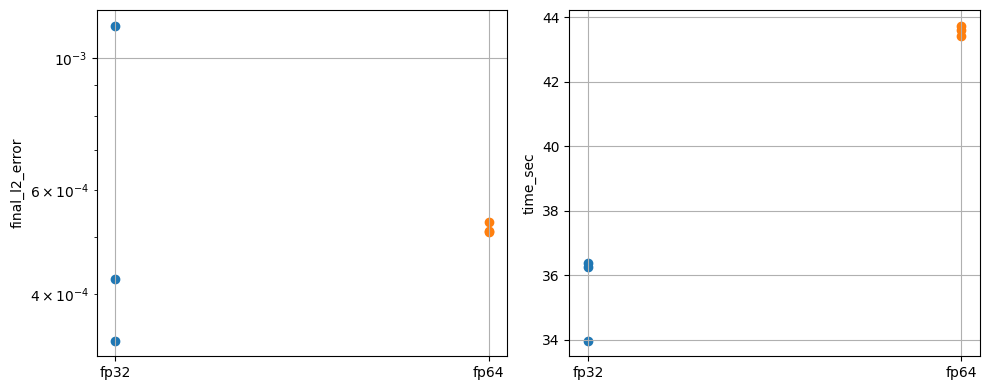

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, dtype in enumerate(["fp32", "fp64"]):
    part = df[df["dtype"] == dtype]
    x = np.zeros(len(part)) + i
    ax[0].scatter(x, part["final_l2_error"])
    ax[1].scatter(x, part["time_sec"])

ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["fp32", "fp64"])
ax[0].set_yscale("log")
ax[0].set_ylabel("final_l2_error")
ax[0].grid(True)

ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["fp32", "fp64"])
ax[1].set_ylabel("time_sec")
ax[1].grid(True)

fig.tight_layout()
plt.show()

## Кривые для seed 0

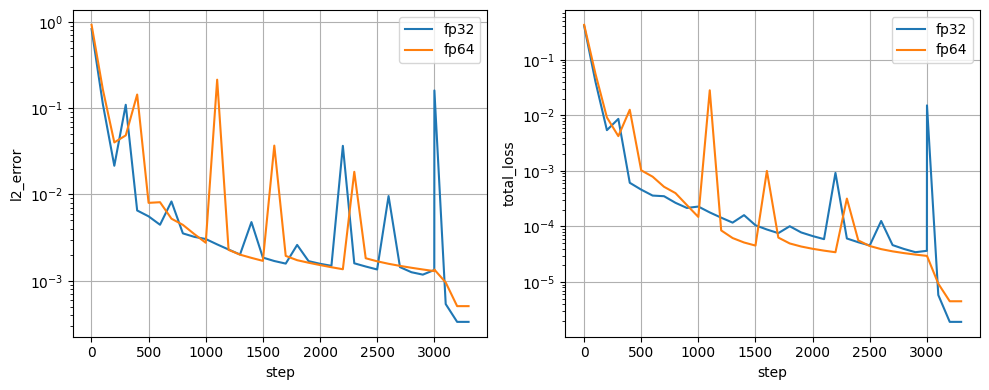

In [11]:
h32 = pd.read_csv("runs/heat1d_fp32_seed0/metrics.csv")
h64 = pd.read_csv("runs/heat1d_fp64_seed0/metrics.csv")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(h32["step"], h32["l2_error"], label="fp32")
ax[0].plot(h64["step"], h64["l2_error"], label="fp64")
ax[0].set_yscale("log")
ax[0].set_xlabel("step")
ax[0].set_ylabel("l2_error")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(h32["step"], h32["total_loss"], label="fp32")
ax[1].plot(h64["step"], h64["total_loss"], label="fp64")
ax[1].set_yscale("log")
ax[1].set_xlabel("step")
ax[1].set_ylabel("total_loss")
ax[1].grid(True)
ax[1].legend()

fig.tight_layout()
plt.show()